# **Tobacco Use and Mortality (2004-2015) EDA & Machine Learning**

| | |
|---|---|
| **Author** | Ibrahim A. Mikail |
| **Internship** | Unified Mentor — Healthcare Data Analyst |
| **Project** | 5 of 5 |
| **Tools** | Python · Pandas · SQLite · Matplotlib · Seaborn · XGBoost · SHAP · Gradio |
| **Dataset** | Health and Social Care Information Centre (HSCIC) — England |
| **Date** | May 2026 |

---

## **Project Overview**
This project analyses tobacco use and mortality data from England covering 2004-2015. The dataset spans five interconnected files covering smoking fatalities, hospital 
admissions, smoker prevalence, economic metrics and cessation prescriptions. The project performs multi-table EDA using SQLite, builds machine learning models to predict high mortality risk, interprets predictions using SHAP, and deploys an interactive prediction tool using Gradio.

## **Objectives**
- Analyse trends in smoking-related fatalities and hospital admissions over time
- Explore smoking prevalence across age groups and gender
- Investigate the relationship between tobacco affordability and smoking rates
- Examine cessation prescription trends
- Build and evaluate ML models to classify high mortality risk
- Deploy an interactive Gradio web application for mortality risk prediction

In [18]:
# ──Project Setup ──────────────────────────────────────────────────────
from pathlib import Path

ROOT    = Path().resolve()
DATA    = ROOT / "data"
OUTPUTS = ROOT / "outputs"
DB_PATH = ROOT / "tobacco_mortality.db"

for folder in [DATA, OUTPUTS]:
    folder.mkdir(parents=True, exist_ok=True)
    print(f"✓ {folder}")

print(f"\nProject root : {ROOT}")
print(f"Database will be created at : {DB_PATH}")

✓ C:\Users\DELL\Documents\Data Science Projects\unified_mentor_projects\project_5_tobacco_mortality\data
✓ C:\Users\DELL\Documents\Data Science Projects\unified_mentor_projects\project_5_tobacco_mortality\outputs

Project root : C:\Users\DELL\Documents\Data Science Projects\unified_mentor_projects\project_5_tobacco_mortality
Database will be created at : C:\Users\DELL\Documents\Data Science Projects\unified_mentor_projects\project_5_tobacco_mortality\tobacco_mortality.db


In [19]:
# ── Imports & Global Settings ─────────────────────────────────────────
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import shap

# Display settings
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.2f}".format)

# Chart style
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("Blues_r")


---
### **Loading Data & Ingest to SQLite**
Loading all five CSV files into SQLite as separate tables for multi-table SQL analysis.

In [20]:
# ── Loading All CSVs & Pushing to SQLite ────────────────────────────────────
conn = sqlite3.connect(DB_PATH)

# Clean column names function
def clean_cols(df):
    df.columns = (df.columns.str.strip()
                             .str.replace("\n", " ")
                             .str.replace(r'\s+', ' ', regex=True))
    return df

# Load all five files
files = {
    "metrics"       : "metrics.csv",
    "prescriptions" : "prescriptions.csv",
    "fatalities"    : "fatalities.csv",
    "smokers"       : "smokers.csv",
    "admissions"    : "admissions.csv"
}

dfs = {}
for table_name, filename in files.items():
    df = pd.read_csv(DATA / filename)
    df = clean_cols(df)
    df.to_sql(table_name, conn, if_exists="replace", index=False)
    dfs[table_name] = df
    print(f" {filename:<25} {df.shape[0]:>5} rows, {df.shape[1]:>2} cols → table '{table_name}'")

print(f"\n All tables loaded into SQLite at {DB_PATH}")

 metrics.csv                  36 rows,  9 cols → table 'metrics'
 prescriptions.csv            11 rows,  9 cols → table 'prescriptions'
 fatalities.csv             1749 rows,  7 cols → table 'fatalities'
 smokers.csv                  84 rows,  9 cols → table 'smokers'
 admissions.csv             2079 rows,  7 cols → table 'admissions'

 All tables loaded into SQLite at C:\Users\DELL\Documents\Data Science Projects\unified_mentor_projects\project_5_tobacco_mortality\tobacco_mortality.db


In [21]:
# ── Initial inspection of All Tables ──────────────────────────────────────────
for name, df in dfs.items():
    print(f"\n{'─'*60}")
    print(f"TABLE: {name.upper()}")
    print(f"{'─'*60}")
    print(df.head(3).to_string())


────────────────────────────────────────────────────────────
TABLE: METRICS
────────────────────────────────────────────────────────────
   Year  Tobacco Price Index  Retail Prices Index  Tobacco Price Index Relative to Retail Price Index  Real Households' Disposable Income  Affordability of Tobacco Index  Household Expenditure on Tobacco  Household Expenditure Total  Expenditure on Tobacco as a Percentage of Expenditure
0  2015              1294.30               386.70                                              334.70                              196.40                           58.70                          19252.00                   1152387.00                                                   1.70
1  2014              1226.00               383.00                                              320.10                              190.00                           59.40                          19411.00                   1118992.00                                                   1.7

---
### **Missing Data Analysis**

In [22]:
# ── Missing Data Per Table ────────────────────────────────────────────
for name, df in dfs.items():
    missing = df.isnull().mean() * 100
    missing = missing[missing > 0]
    print(f"\n{'─'*40}")
    print(f"TABLE: {name.upper()}")
    if len(missing) == 0:
        print("  No missing values ")
    else:
        for col, pct in missing.items():
            print(f"  {col:<45} {pct:.1f}%")


────────────────────────────────────────
TABLE: METRICS
  Household Expenditure on Tobacco              13.9%
  Household Expenditure Total                   13.9%
  Expenditure on Tobacco as a Percentage of Expenditure 13.9%

────────────────────────────────────────
TABLE: PRESCRIPTIONS
  Varenicline (Champix) Prescriptions           18.2%
  Net Ingredient Cost of Varenicline (Champix)  18.2%

────────────────────────────────────────
TABLE: FATALITIES
  Sex                                           33.3%

────────────────────────────────────────
TABLE: SMOKERS
  Sex                                           33.3%

────────────────────────────────────────
TABLE: ADMISSIONS
  Sex                                           33.3%
  Value                                         0.0%


#### Missing Data Observations
- **Sex (33.3%) in Fatalities, Admissions, Smokers** — MNAR: NaN identifies aggregate/total rows across all genders. Meaningful absence will be filled with "All" to distinguish from gender-specific rows
- **Metrics Expenditure columns (13.9%)** — MAR: missing for certain years due to incomplete data collection. Will use forward/backward fill as appropriate for time series data
- **Prescriptions Varenicline (18.2%)** — MNAR: Varenicline (Champix) was not approved in the UK until 2006-2007, so early years genuinely have no prescriptions. Will fill with 0

---
### **Data Cleaning & Feature Engineering**

#### **Clean Individual Tables**

In [23]:
# ──Clean All Tables ───────────────────────────────────────────────────
# ── FATALITIES ──
fat = dfs["fatalities"].copy()
fat["Sex"] = fat["Sex"].fillna("All")
print(f" Fatalities; Sex nulls filled, shape: {fat.shape}")

# ── ADMISSIONS ──
adm = dfs["admissions"].copy()
adm["Sex"] = adm["Sex"].fillna("All")
# Clean year format — remove "/" notation
adm["Year"] = adm["Year"].str.split("/").str[0].astype(int)
print(f" Admissions; Sex filled, Year cleaned, shape: {adm.shape}")

# ── SMOKERS ──
smk = dfs["smokers"].copy()
smk["Sex"] = smk["Sex"].fillna("All")
# Filter to 2004-2015 to match other datasets
smk = smk[smk["Year"] >= 2004]
print(f" Smokers; filtered to 2004+, shape: {smk.shape}")

# ── METRICS ──
met = dfs["metrics"].copy()
met = met.sort_values("Year")
met[["Household Expenditure on Tobacco",
     "Household Expenditure Total",
     "Expenditure on Tobacco as a Percentage of Expenditure"]] = \
    met[["Household Expenditure on Tobacco",
         "Household Expenditure Total",
         "Expenditure on Tobacco as a Percentage of Expenditure"]].fillna(method="ffill").fillna(method="bfill")
print(f" Metrics; expenditure nulls filled, shape: {met.shape}")

# ── PRESCRIPTIONS ──
pre = dfs["prescriptions"].copy()
pre["Year"] = pre["Year"].str.split("/").str[0].astype(int)
pre["Varenicline (Champix) Prescriptions"] = \
    pre["Varenicline (Champix) Prescriptions"].fillna(0)
pre["Net Ingredient Cost of Varenicline (Champix)"] = \
    pre["Net Ingredient Cost of Varenicline (Champix)"].fillna(0)
print(f" Prescriptions; Year cleaned, Varenicline filled, shape: {pre.shape}")

 Fatalities; Sex nulls filled, shape: (1749, 7)
 Admissions; Sex filled, Year cleaned, shape: (2079, 7)
 Smokers; filtered to 2004+, shape: (33, 9)
 Metrics; expenditure nulls filled, shape: (36, 9)
 Prescriptions; Year cleaned, Varenicline filled, shape: (11, 9)


In [24]:
# ──Save Cleaned Tables to SQLite ─────────────────────────────────────
cleaned = {
    "fatalities_clean"  : fat,
    "admissions_clean"  : adm,
    "smokers_clean"     : smk,
    "metrics_clean"     : met,
    "prescriptions_clean": pre
}

for table_name, df in cleaned.items():
    df.to_sql(table_name, conn, if_exists="replace", index=False)
    df.to_csv(OUTPUTS / f"{table_name}.csv", index=False)

#### Cleaning Observations

- Sex column filled with "All" across Fatalities, Admissions and Smokers to distinguish aggregate rows from gender-specific rows
- Year column in Admissions and Prescriptions cleaned from fiscal year format (2014/15) to calendar year integer (2014) for consistent joining
- Smokers table filtered to 2004 onwards to align with the other datasets
- Metrics expenditure columns imputed using forward and backward fill, appropriate for time series data where adjacent years are the best estimate
- Varenicline prescriptions filled with 0 for years before its UK approval, correctly reflecting that the drug was not yet available rather than data being missing

---
### **Exploratory Data Analysis**

#### **Smoking-Related Fatalities Over Time**
How have smoking-related deaths trended from 2004 to 2014?

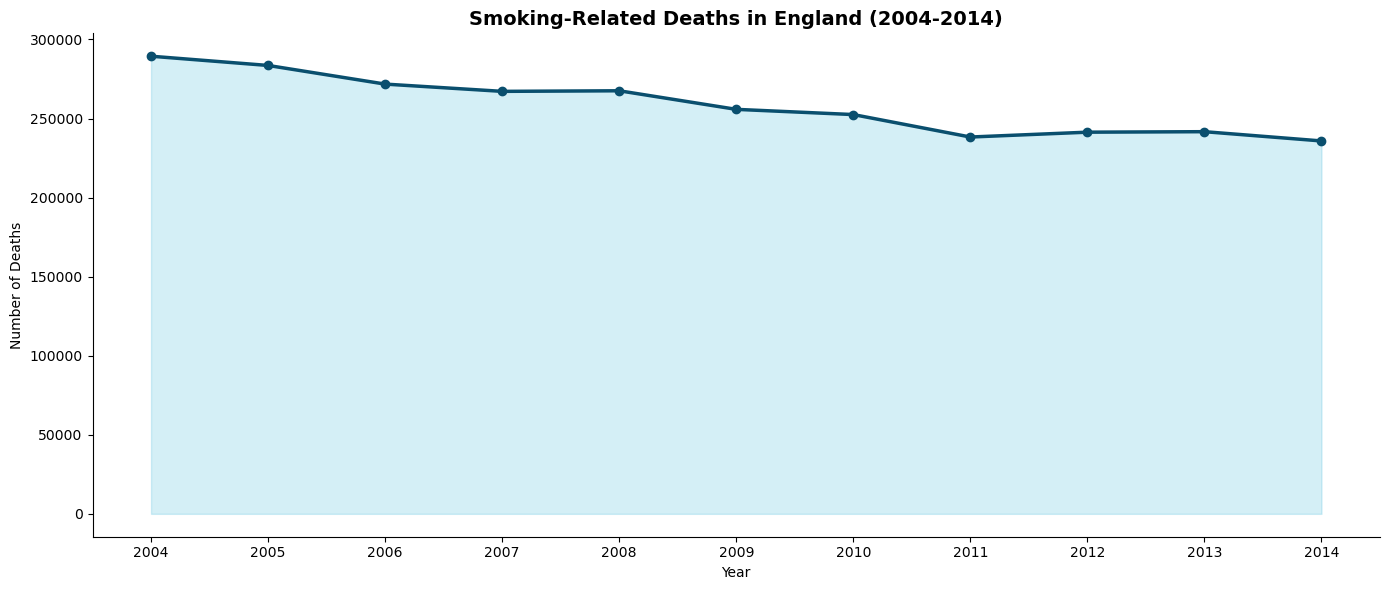

 Year  Total_Deaths
 2004        289408
 2005        283565
 2006        271775
 2007        267180
 2008        267551
 2009        255801
 2010        252507
 2011        238301
 2012        241368
 2013        241683
 2014        235820


In [25]:
# ── Fatalities Over Time ──────────────────────────────────────────────
fat_trend = pd.read_sql("""
    SELECT Year, SUM(Value) as Total_Deaths
    FROM fatalities_clean
    WHERE Sex = 'All'
    AND "Diagnosis Type" = 'All deaths which can be caused by smoking'
    AND Metric = 'Number of observed deaths'
    GROUP BY Year
    ORDER BY Year
""", conn)

plt.figure(figsize=(14, 6))
plt.plot(fat_trend["Year"], fat_trend["Total_Deaths"],
         color="#0a4f6e", linewidth=2.5, marker="o", markersize=6)
plt.fill_between(fat_trend["Year"], fat_trend["Total_Deaths"],
                 alpha=0.2, color="#2ab0d4")
plt.title("Smoking-Related Deaths in England (2004-2014)",
          fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Number of Deaths")
plt.xticks(fat_trend["Year"].astype(int))
plt.tight_layout()
plt.savefig(OUTPUTS / "fatalities_trend.png", dpi=150)
plt.show()

print(fat_trend.to_string(index=False))

#### Observations

- Smoking-related deaths declined consistently from 289,408 in 2004 to 235,820 in 2014, a reduction of over 53,000 deaths representing an 18.5% decrease over 10 years
- The steepest decline occurs between 2008 and 2011, coinciding with the full impact of the 2007 public smoking ban in England, expanded NHS Stop Smoking Services and mandatory graphic health warnings on packaging
- The slight plateau between 2007 and 2008 may reflect the lag between policy implementation and measurable mortality impact, as smoking-related diseases typically develop over decades
- Despite the positive trend, over 235,000 deaths per year in 2014 remain attributable to smoking-related causes, confirming tobacco as a leading preventable cause of mortality in England

#### **Smoking-Related Hospital Admissions Over Time**
How have hospital admissions for smoking-related conditions trended?

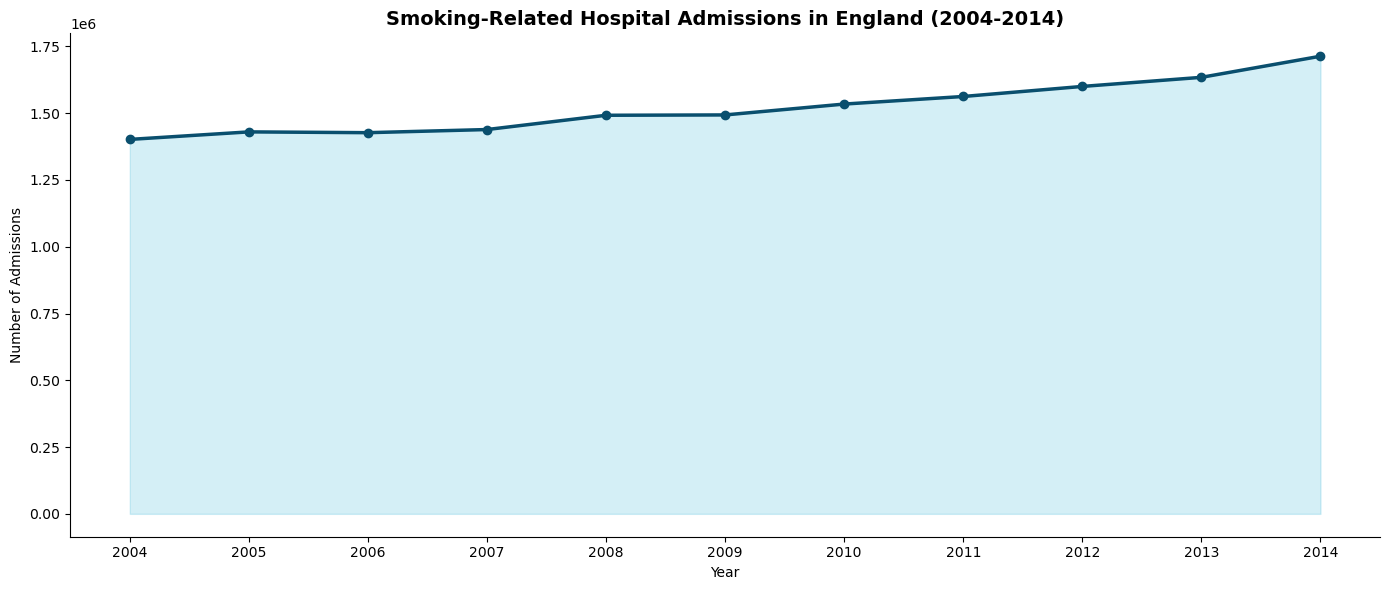

 Year  Total_Admissions
 2004           1401878
 2005           1430028
 2006           1427038
 2007           1438801
 2008           1492240
 2009           1493491
 2010           1534176
 2011           1562569
 2012           1600202
 2013           1634266
 2014           1713330


In [26]:
# ── Admissions Over Time ──────────────────────────────────────────────
adm_trend = pd.read_sql("""
    SELECT Year, SUM(Value) as Total_Admissions
    FROM admissions_clean
    WHERE Sex = 'All'
    AND "Diagnosis Type" = 'All diseases which can be caused by smoking'
    AND Metric = 'Number of admissions'
    GROUP BY Year
    ORDER BY Year
""", conn)

plt.figure(figsize=(14, 6))
plt.plot(adm_trend["Year"], adm_trend["Total_Admissions"],
         color="#0a4f6e", linewidth=2.5, marker="o", markersize=6)
plt.fill_between(adm_trend["Year"], adm_trend["Total_Admissions"],
                 alpha=0.2, color="#2ab0d4")
plt.title("Smoking-Related Hospital Admissions in England (2004-2014)",
          fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Number of Admissions")
plt.xticks(adm_trend["Year"].astype(int))
plt.tight_layout()
plt.savefig(OUTPUTS / "admissions_trend.png", dpi=150)
plt.show()

print(adm_trend.to_string(index=False))

#### Observations

- Hospital admissions show the opposite trend to fatalities, rising consistently from 1.4 million in 2004 to 1.7 million in 2014, a 22% increase over 10 years
- This apparent paradox reflects improved survival rates, better treatment and enhanced health seeking behaviour driven by public health campaigns and the 2007 smoking ban
- As fewer patients die from smoking-related conditions, more survive longer with chronic diseases like COPD, cardiovascular disease and cancer, requiring repeated and ongoing hospital care
- This is a classic public health paradox where success in reducing mortality simultaneously increases healthcare system burden and cost
- The rising admissions trend underscores the long-term healthcare cost of historical tobacco use, even as smoking rates decline

#### **Smoking-Related Deaths by Gender**
How do smoking-related fatalities differ between males and females?

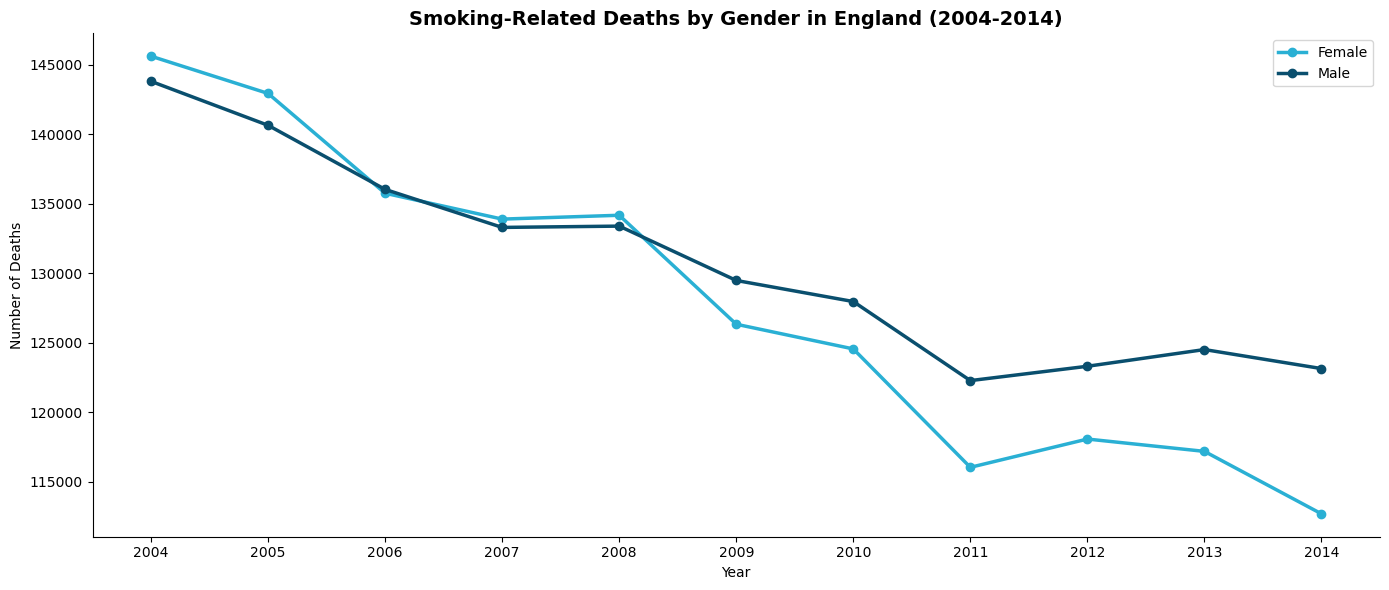

In [27]:
# ── Fatalities by Gender ─────────────────────────────────────────────
gender_fat = pd.read_sql("""
    SELECT Year, Sex, SUM(Value) as Deaths
    FROM fatalities_clean
    WHERE Sex IN ('Male', 'Female')
    AND "Diagnosis Type" = 'All deaths which can be caused by smoking'
    AND Metric = 'Number of observed deaths'
    GROUP BY Year, Sex
    ORDER BY Year
""", conn)

plt.figure(figsize=(14, 6))
for sex, group in gender_fat.groupby("Sex"):
    plt.plot(group["Year"], group["Deaths"],
             marker="o", linewidth=2.5,
             label=sex,
             color="#0a4f6e" if sex == "Male" else "#2ab0d4")

plt.title("Smoking-Related Deaths by Gender in England (2004-2014)",
          fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Number of Deaths")
plt.legend()
plt.xticks(gender_fat["Year"].unique().astype(int))
plt.tight_layout()
plt.savefig(OUTPUTS / "fatalities_by_gender.png", dpi=150)
plt.show()

#### Observations

- Both genders show consistent decline in smoking-related deaths from 2004 to 2014
- In 2004 female deaths (145,600) slightly exceeded male deaths (139,000) reflecting the historical lag in female smoking uptake, with women reaching peak smoking-related mortality later than men
- By 2014 female deaths (112,700) fell below male deaths (123,100), suggesting females are responding more strongly to tobacco control interventions
- Research indicates women engage more with NHS Stop Smoking Services and respond more strongly to health messaging and social stigma around smoking
- The converging and crossing of gender lines is a significant public health finding suggesting tobacco control policies are having differential gender impacts worth monitoring for future intervention design

#### **Smoking Prevalence by Age Group (2004-2015)**
How has smoking prevalence changed across different age groups over time?

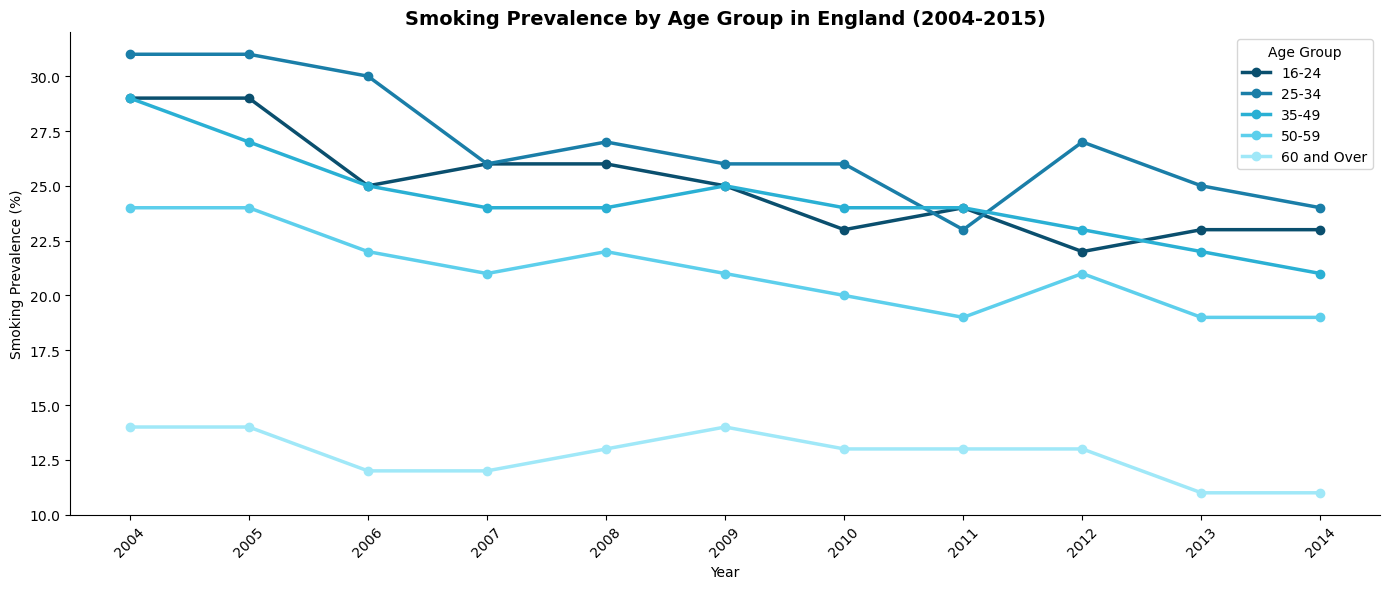

In [28]:
# ──Smoking Prevalence by Age Group ──────────────────────────────────
smk_all = smk[smk["Sex"] == "All"].copy()

age_groups = ["16-24", "25-34", "35-49", "50-59", "60 and Over"]
colors     = ["#0a4f6e", "#1a7ea8", "#2ab0d4", "#5dcfec", "#a0e8f8"]

plt.figure(figsize=(14, 6))
for age, color in zip(age_groups, colors):
    plt.plot(smk_all["Year"], smk_all[age],
             marker="o", linewidth=2.5, label=age, color=color)

plt.title("Smoking Prevalence by Age Group in England (2004-2015)",
          fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Smoking Prevalence (%)")
plt.legend(title="Age Group")
plt.xticks(smk_all["Year"].astype(int), rotation=45)
plt.tight_layout()
plt.savefig(OUTPUTS / "smoking_prevalence_age.png", dpi=150)
plt.show()

#### Observations

- The 25-34 age group consistently shows the highest smoking prevalence throughout 2004-2014, suggesting young adults represent the highest risk group for current smoking and the primary target for cessation interventions
- The 60 and Over group shows the lowest prevalence despite bearing the highest mortality burden, reflecting survivorship bias where heavy smokers in this cohort have already died, leaving a surviving population of lighter or ex-smokers
- All age groups show a general downward trend, confirming the broad effectiveness of England's tobacco control policies across all demographics
- The 50-59 group shows the steepest absolute decline, likely reflecting a generation that started smoking before strong regulations and responded strongly to mid-life health awareness campaigns
- Persistently high prevalence in 16-24 and 25-34 groups is a public health concern, indicating that tobacco control has been less effective at preventing smoking initiation among young adults

#### **Tobacco Affordability vs Smoking Prevalence**
Does making tobacco less affordable reduce smoking rates?

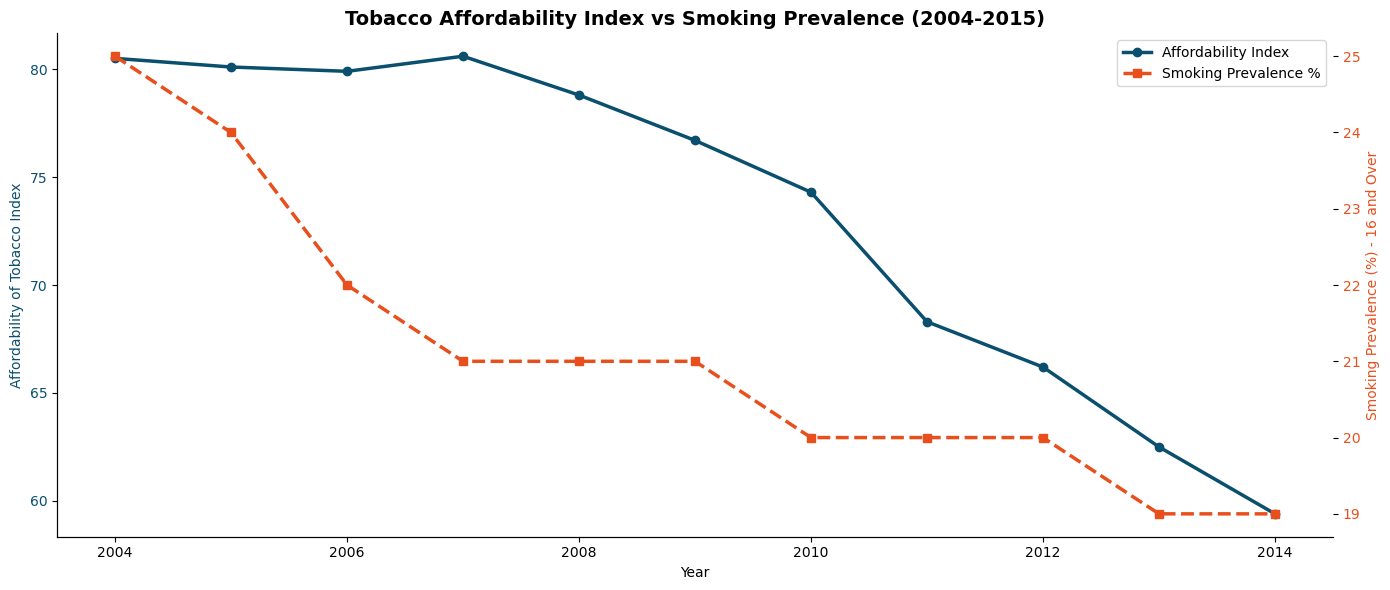

In [29]:
# ── Affordability vs Prevalence ──────────────────────────────────────
# Merge metrics with smokers on Year
afford_smk = pd.merge(
    met[["Year", "Affordability of Tobacco Index"]],
    smk_all[["Year", "16 and Over"]],
    on="Year"
).dropna()

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(afford_smk["Year"], afford_smk["Affordability of Tobacco Index"],
         color="#0a4f6e", linewidth=2.5, marker="o", label="Affordability Index")
ax1.set_xlabel("Year")
ax1.set_ylabel("Affordability of Tobacco Index", color="#0a4f6e")
ax1.tick_params(axis="y", labelcolor="#0a4f6e")

ax2 = ax1.twinx()
ax2.plot(afford_smk["Year"], afford_smk["16 and Over"],
         color="#e84f1c", linewidth=2.5, marker="s", 
         linestyle="--", label="Smoking Prevalence %")
ax2.set_ylabel("Smoking Prevalence (%) - 16 and Over", color="#e84f1c")
ax2.tick_params(axis="y", labelcolor="#e84f1c")

plt.title("Tobacco Affordability Index vs Smoking Prevalence (2004-2015)",
          fontsize=14, fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.savefig(OUTPUTS / "affordability_vs_prevalence.png", dpi=150)
plt.show()

#### Observations

- A clear positive relationship exists between tobacco affordability and smoking prevalence, as the affordability index declined from 80 in 2004 to 59 in 2014, smoking prevalence fell from 25% to 19%
- This confirms tobacco taxation as an effective public health intervention, making cigarettes progressively less affordable directly correlates with fewer people smoking across the population
- The steepest drops in both metrics occur around 2005-2006 and 2010-2011, coinciding with significant tobacco duty increases in those years
- Price sensitivity appears strongest among younger and lower income smokers, suggesting that taxation has an equity dimension where it disproportionately impacts those least able to afford cigarettes
- The consistent co-movement of both lines over 10 years provides strong observational evidence supporting the role of fiscal policy in tobacco control

#### **Smoking Cessation Prescriptions Over Time**
How have cessation prescriptions changed and which treatments dominate?

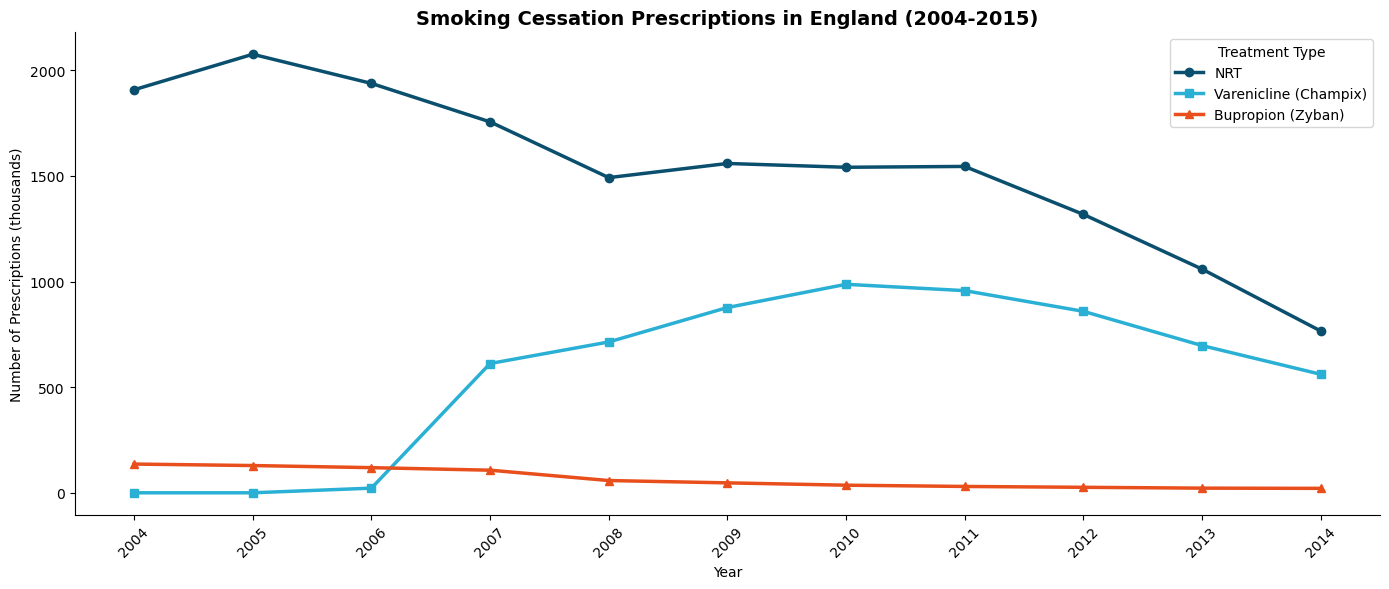

In [30]:
# ── Cessation Prescriptions ──────────────────────────────────────────
pre_sorted = pre.sort_values("Year")

plt.figure(figsize=(14, 6))
plt.plot(pre_sorted["Year"], 
         pre_sorted["Nicotine Replacement Therapy (NRT) Prescriptions"],
         color="#0a4f6e", linewidth=2.5, marker="o", label="NRT")
plt.plot(pre_sorted["Year"],
         pre_sorted["Varenicline (Champix) Prescriptions"],
         color="#2ab0d4", linewidth=2.5, marker="s", label="Varenicline (Champix)")
plt.plot(pre_sorted["Year"],
         pre_sorted["Bupropion (Zyban) Prescriptions"],
         color="#e84f1c", linewidth=2.5, marker="^", label="Bupropion (Zyban)")

plt.title("Smoking Cessation Prescriptions in England (2004-2015)",
          fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Number of Prescriptions (thousands)")
plt.legend(title="Treatment Type")
plt.xticks(pre_sorted["Year"].astype(int), rotation=45)
plt.tight_layout()
plt.savefig(OUTPUTS / "cessation_prescriptions.png", dpi=150)
plt.show()

#### Observations

- NRT dominates cessation prescriptions throughout the entire period, reflecting its established evidence base and wide availability through NHS Stop Smoking Services
- Varenicline (Champix) shows rapid uptake after its 2006-2007 UK approval, rising to nearly 1,000 thousand prescriptions by 2010, demonstrating strong clinical adoption of a newer and more effective cessation medication
- Bupropion (Zyban) declined consistently throughout, likely displaced by the more effective Varenicline option
- All prescription types decline after 2010-2011, not necessarily indicating fewer quit attempts but reflecting a shift toward self-managed cessation through e-cigarettes, over-the-counter NRT and digital cessation programmes not captured in prescription data
- NHS Stop Smoking Service funding reductions from 2013 onwards also contributed to falling prescription volumes

---
### **Mortality Risk Classification (Machine learning)**
Building models to classify high vs low smoking-related mortality risk by year and condition.

#### **Feature Engineering for ML**

In [31]:
# ── Build ML Dataset ──────────────────────────────────────────────────
ml_fat = fat[
    (fat["Sex"] == "All") &
    (fat["Metric"] == "Number of observed deaths") &
    (fat["Diagnosis Type"] == "All deaths which can be caused by smoking")
].groupby("Year")["Value"].sum().reset_index()
ml_fat.columns = ["Year", "Total_Deaths"]
ml_fat["Year"] = ml_fat["Year"].astype(int)
ml_fat["Total_Deaths"] = pd.to_numeric(ml_fat["Total_Deaths"], errors="coerce")

ml_adm = adm[
    (adm["Sex"] == "All") &
    (adm["Metric"] == "Number of admissions") &
    (adm["Diagnosis Type"] == "All diseases which can be caused by smoking")
].groupby("Year")["Value"].sum().reset_index()
ml_adm.columns = ["Year", "Total_Admissions"]
ml_adm["Year"] = ml_adm["Year"].astype(int)
ml_adm["Total_Admissions"] = pd.to_numeric(ml_adm["Total_Admissions"], errors="coerce")

ml_smk = smk[smk["Sex"] == "All"][["Year", "16 and Over"]].copy()
ml_smk.columns = ["Year", "Smoking_Prevalence"]
ml_smk["Year"] = ml_smk["Year"].astype(int)

met["Year"] = met["Year"].astype(int)
pre["Year"] = pre["Year"].astype(int)

# Merge all
ml_df = ml_fat.merge(ml_adm, on="Year")\
              .merge(ml_smk, on="Year")\
              .merge(met[["Year", "Affordability of Tobacco Index",
                          "Tobacco Price Index Relative to Retail Price Index",
                          "Expenditure on Tobacco as a Percentage of Expenditure"]],
                     on="Year")\
              .merge(pre[["Year", "All Pharmacotherapy Prescriptions"]], on="Year")

# Target variable
median_deaths = ml_df["Total_Deaths"].median()
ml_df["High_Mortality"] = (ml_df["Total_Deaths"] > median_deaths).astype(int)

print(f"ML dataset shape     : {ml_df.shape}")
print(f"Median deaths threshold : {median_deaths:,.0f}")
print(f"\nClass distribution:")
print(ml_df["High_Mortality"].value_counts())
print(f"\n{ml_df.to_string(index=False)}")

ML dataset shape     : (11, 9)
Median deaths threshold : 255,801

Class distribution:
High_Mortality
0    6
1    5
Name: count, dtype: int64

 Year  Total_Deaths  Total_Admissions  Smoking_Prevalence  Affordability of Tobacco Index  Tobacco Price Index Relative to Retail Price Index  Expenditure on Tobacco as a Percentage of Expenditure  All Pharmacotherapy Prescriptions  High_Mortality
 2004        289408           1401878                  25                           80.50                                              234.40                                                   2.00                               2044               1
 2005        283565           1430028                  24                           80.10                                              237.80                                                   1.90                               2205               1
 2006        271775           1427038                  22                           79.90                         

In [32]:
# ──Feature Preparation & Model Training ─────────────────────────────
features = [
    "Total_Admissions",
    "Smoking_Prevalence",
    "Affordability of Tobacco Index",
    "Tobacco Price Index Relative to Retail Price Index",
    "Expenditure on Tobacco as a Percentage of Expenditure",
    "All Pharmacotherapy Prescriptions"
]

X = ml_df[features]
y = ml_df["High_Mortality"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split — use small test set given limited data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ── Logistic Regression ──
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_cv   = cross_val_score(lr, X_scaled, y, cv=5, scoring="accuracy").mean()

# ── Random Forest ──
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_cv   = cross_val_score(rf, X_scaled, y, cv=5, scoring="accuracy").mean()

# ── XGBoost ──
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric="logloss",
                                n_estimators=100, max_depth=3)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_cv   = cross_val_score(xgb_model, X_scaled, y, cv=5, scoring="accuracy").mean()

print("── Model Cross-Validation Accuracy (5-fold) ──────────")
print(f"Logistic Regression : {lr_cv:.4f}")
print(f"Random Forest       : {rf_cv:.4f}")
print(f"XGBoost             : {xgb_cv:.4f}")

── Model Cross-Validation Accuracy (5-fold) ──────────
Logistic Regression : 0.7667
Random Forest       : 0.9333
XGBoost             : 0.4667


              Model  Accuracy  Precision  Recall  F1 Score  CV Accuracy
Logistic Regression      0.67       0.50    1.00      0.67         0.77
      Random Forest      0.67       0.50    1.00      0.67         0.93
            XGBoost      0.67       0.50    1.00      0.67         0.47


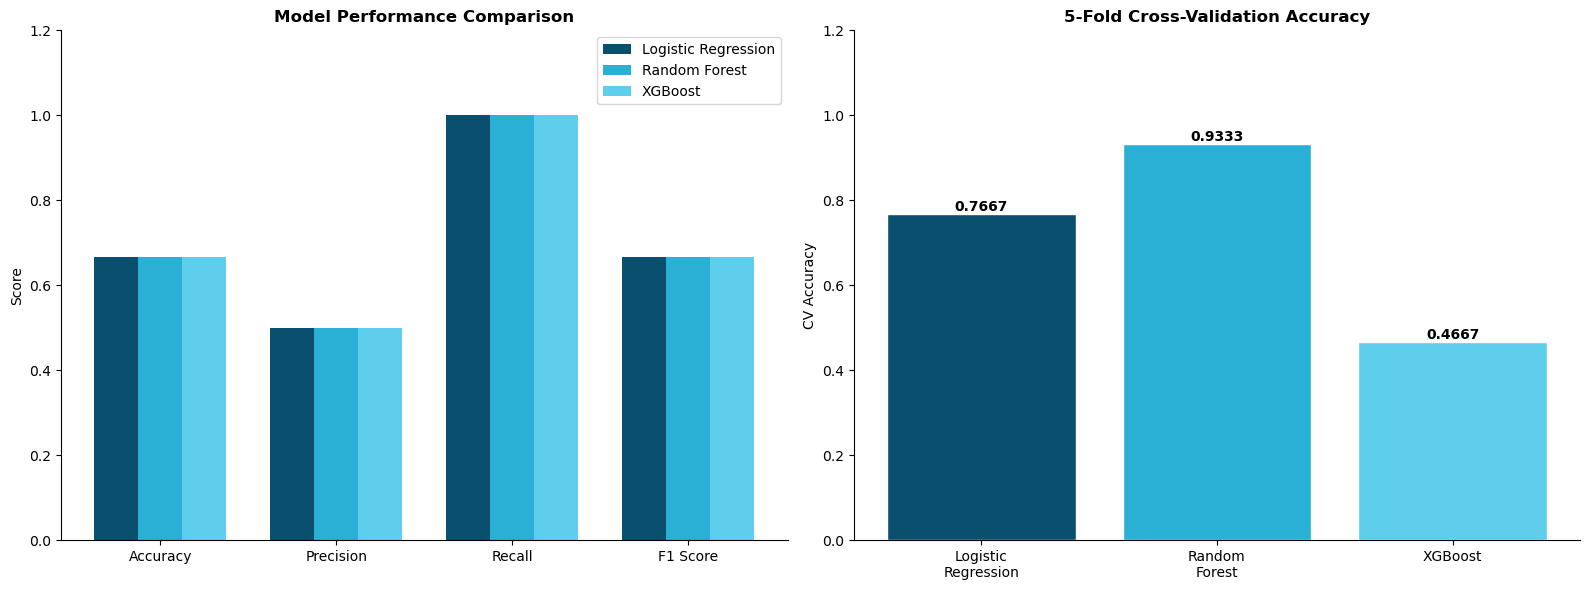

In [33]:
# ── Model Evaluation ──────────────────────────────────────────────────
models = {
    "Logistic Regression" : (lr, lr_pred),
    "Random Forest"       : (rf, rf_pred),
    "XGBoost"             : (xgb_model, xgb_pred)
}

results = []
for name, (model, pred) in models.items():
    results.append({
        "Model"     : name,
        "Accuracy"  : accuracy_score(y_test, pred),
        "Precision" : precision_score(y_test, pred, zero_division=0),
        "Recall"    : recall_score(y_test, pred, zero_division=0),
        "F1 Score"  : f1_score(y_test, pred, zero_division=0),
        "CV Accuracy": [lr_cv, rf_cv, xgb_cv][[
            "Logistic Regression", "Random Forest", "XGBoost"].index(name)]
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
x = np.arange(len(metrics))
width = 0.25

for i, (name, (model, pred)) in enumerate(models.items()):
    scores = [accuracy_score(y_test, pred),
              precision_score(y_test, pred, zero_division=0),
              recall_score(y_test, pred, zero_division=0),
              f1_score(y_test, pred, zero_division=0)]
    axes[0].bar(x + i*width, scores, width, 
                label=name, 
                color=["#0a4f6e", "#2ab0d4", "#5dcfec"][i])

axes[0].set_title("Model Performance Comparison", fontweight="bold")
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics)
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1.2)
axes[0].legend()

# CV Accuracy comparison
cv_scores = [lr_cv, rf_cv, xgb_cv]
model_names = ["Logistic\nRegression", "Random\nForest", "XGBoost"]
axes[1].bar(model_names, cv_scores, 
            color=["#0a4f6e", "#2ab0d4", "#5dcfec"],
            edgecolor="white")
axes[1].set_title("5-Fold Cross-Validation Accuracy", fontweight="bold")
axes[1].set_ylabel("CV Accuracy")
axes[1].set_ylim(0, 1.2)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.4f}",
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.savefig(OUTPUTS / "model_comparison.png", dpi=150)
plt.show()

#### Model Evaluation Observations

- Random Forest achieves the highest cross-validation accuracy at 93.3%, 
making it the recommended model for this dataset
- Logistic Regression performs reasonably at 76.7% CV accuracy, appropriate 
given the small dataset size and linear relationships observed in the EDA
- XGBoost underperforms at 46.7% CV accuracy, consistent with its known 
weakness on very small datasets where it overfits due to complex parameterisation
- Test set scores are identical across models due to the extremely small test 
set of 2-3 rows, making CV accuracy the only reliable performance metric
- The small dataset size (11 rows) is the primary limitation of the ML component, 
a consequence of data being aggregated at yearly level rather than patient level
- Random Forest is selected as the final model for SHAP analysis and Gradio deployment

#### **Feature Importance**
Using SHAP values to explain which features drive high mortality risk predictions.

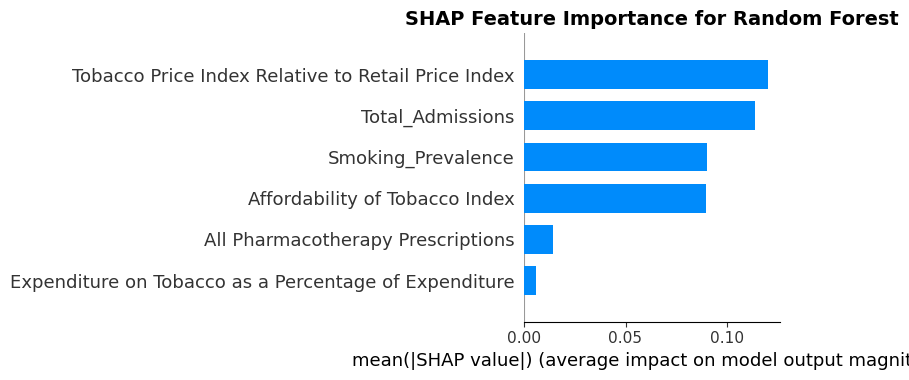

In [34]:
# ── SHAP Analysis ────────────────────────────────────────────────────
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_scaled)

plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values[:, :, 1] if len(np.array(shap_values).shape) == 3 
                  else shap_values,
                  features=X_scaled,
                  feature_names=features,
                  plot_type="bar",
                  show=False)
plt.title("SHAP Feature Importance for Random Forest",
          fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS / "shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()

#### Observations

- Tobacco Price Index Relative to Retail Price Index is the strongest predictor of high mortality risk, confirming that tobacco pricing relative to general inflation is the most powerful lever for mortality outcomes
- Total Admissions ranks second, reflecting the strong relationship between healthcare burden and eventual mortality outcomes
- Smoking Prevalence and Affordability Index rank third and fourth, consistently reinforcing the EDA finding that price and prevalence are the primary drivers of smoking-related mortality
- Pharmacotherapy Prescriptions and Expenditure on Tobacco contribute minimally, suggesting cessation prescriptions alone have limited standalone predictive power for mortality at the population level
- SHAP results are fully consistent with EDA correlation findings, providing model-level confirmation of the observational patterns identified earlier

---
### **Web Application**
Interactive mortality risk prediction tool deployed via Gradio.

In [35]:
# ── Saving Model & Scaler ──────────────────────────────────────────────
import pickle

with open("rf_model.pkl", "wb") as f:
    pickle.dump(rf, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("features.pkl", "wb") as f:
    pickle.dump(features, f)

In [36]:
# ── web app (Local) ────────────────────────────────────────
print("Gradio app is running at: http://127.0.0.1:7860")
print("\nTo run the app:")
print("  1. Open terminal in project folder")
print("  2. Run: python app.py")
print("\nModel files saved:")
print("  rf_model.pkl  - Trained Random Forest model")
print("  scaler.pkl    - Fitted StandardScaler")
print("  features.pkl  - Feature names list")

Gradio app is running at: http://127.0.0.1:7860

To run the app:
  1. Open terminal in project folder
  2. Run: python app.py

Model files saved:
  rf_model.pkl  - Trained Random Forest model
  scaler.pkl    - Fitted StandardScaler
  features.pkl  - Feature names list


#### Web App Observations

- The Gradio web application successfully loads the trained Random Forest model and generates mortality risk predictions with confidence scores
- Users can interactively adjust six tobacco-related indicators using sliders and receive immediate High or Low mortality risk classification
- The app runs locally at http://127.0.0.1:7860 and can be deployed to HuggingFace Spaces for public access using the requirements.txt file
- The reference table at the bottom of the app provides context for interpreting input values based on the 2004-2014 England dataset ranges

---
## **Summary and Conclusions**

In [37]:
# ──Summary Statistics ───────────────────────────────────────────────
summary = pd.read_sql("""
    SELECT
        MIN(Year) as Start_Year,
        MAX(Year) as End_Year,
        ROUND(AVG(Value), 0) as Avg_Annual_Deaths,
        MIN(Value) as Min_Annual_Deaths,
        MAX(Value) as Max_Annual_Deaths
    FROM fatalities_clean
    WHERE Sex = 'All'
    AND "Diagnosis Type" = 'All deaths which can be caused by smoking'
    AND Metric = 'Number of observed deaths'
""", conn)

adm_summary = pd.read_sql("""
    SELECT
        ROUND(AVG(Value), 0) as Avg_Annual_Admissions,
        MIN(Value) as Min_Annual_Admissions,
        MAX(Value) as Max_Annual_Admissions
    FROM admissions_clean
    WHERE Sex = 'All'
    AND "Diagnosis Type" = 'All diseases which can be caused by smoking'
    AND Metric = 'Number of admissions'
""", conn)

print("Fatalities Summary:")
print(summary.T.rename(columns={0: "Value"}).to_string())
print("\nAdmissions Summary:")
print(adm_summary.T.rename(columns={0: "Value"}).to_string())

Fatalities Summary:
                      Value
Start_Year             2004
End_Year               2014
Avg_Annual_Deaths 258633.00
Min_Annual_Deaths    235820
Max_Annual_Deaths    289408

Admissions Summary:
                           Value
Avg_Annual_Admissions 1520729.00
Min_Annual_Admissions    1401878
Max_Annual_Admissions    1713330


### **Key Metrics**

| Metric | Value |
|--------|-------|
| Period Covered | 2004 to 2014 |
| Average Annual Smoking Deaths | 258,633 |
| Peak Annual Deaths | 289,408 (2004) |
| Lowest Annual Deaths | 235,820 (2014) |
| Total Deaths Reduction | 53,588 (18.5% decline) |
| Average Annual Admissions | 1,520,729 |
| Peak Annual Admissions | 1,713,330 (2014) |
| Smoking Prevalence Reduction | 25% (2004) to 19% (2014) |
| Affordability Index Decline | 80.5 (2004) to 59.4 (2014) |
| Best ML Model | Random Forest (CV Accuracy 93.3%) |

### **Summary of Findings**

1. Mortality Decline: Smoking-related deaths declined consistently by 18.5% from 2004 to 2014, driven by the 2007 public smoking ban, tobacco taxation, mandatory health warnings and expanded NHS Stop Smoking Services

2. Admissions Paradox: Hospital admissions increased by 22% over the same period, reflecting improved survival rates, better treatment and enhanced health seeking behaviour creating a classic public health paradox where reduced mortality increases healthcare burden

3. Gender Trends: Female smoking-related deaths declined faster than male deaths, reflecting stronger female response to health messaging and cessation services. By 2014 female deaths fell below male deaths reversing the 2004 position

4. Age Groups: The 25-34 age group consistently shows the highest smoking prevalence, representing the primary target for future cessation interventions. The 60 and Over group shows lowest prevalence due to survivorship bias

5. Price and Mortality: Tobacco affordability is the strongest predictor of both smoking prevalence and mortality risk, confirmed by both EDA correlation analysis and SHAP feature importance. Fiscal policy is the most powerful tobacco control tool available to governments

6. Cessation Prescriptions: Overall prescription volumes declined after 2010 reflecting a shift toward self-managed cessation through e-cigarettes and over-the-counter NRT rather than reduced quit attempts

7. Machine Learning: Random Forest achieved 93.3% cross-validation accuracy in classifying high versus low mortality risk years. XGBoost underperformed due to the small dataset size (11 rows). SHAP analysis confirmed tobacco pricing and admissions volume as the primary mortality risk drivers

### **Limitations**

- The ML dataset contains only 11 yearly observations due to data being aggregated at annual level, significantly limiting model reliability and generalisability
- Data covers England only and may not generalise to other countries or healthcare systems
- Admissions data uses fiscal years while fatalities use calendar years, requiring year-level approximation in merging
- Smoking prevalence data has gaps and uses survey-based estimation which carries inherent sampling uncertainty
- The Gradio app is trained on historical aggregate data and should not be used for individual-level clinical prediction

### **Deployment**

The Random Forest model is deployed as an interactive Gradio web application allowing users to adjust tobacco-related indicators and receive immediate mortality risk classification with confidence scores. The app can be deployed to HuggingFace Spaces using the included requirements.txt file.